# C02 财务衍生宏观因子
这一节的主线，是把“交易数据”继续往前推进，开始回答更像研究员会问的问题：

> 除了价格本身，我们还能从哪些数据里提取有信息含量的特征？

本节会从三类数据来回答这个问题：
1. 财务数据：公司经营和估值
2. 衍生因子：从价格和成交量再加工出来的特征
3. 宏观变量：公司之外的市场环境


In [ ]:
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
UNIVERSE = ["000001.XSHE", "000002.XSHE", "600000.XSHG", "601318.XSHG"]
# 000001.XSHE: 平安银行
# 000002.XSHE: 万科A
# 600000.XSHG: 浦发银行
# 601318.XSHG: 中国平安

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from matplotlib import font_manager

# Configure matplotlib font fallback for Chinese titles in notebooks
preferred_fonts = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", category=UserWarning, module="IPython.core.pylabtools")
warnings.filterwarnings("ignore", message=r"Glyph .* missing from current font")


import rqdatac

# 把教育版 license 直接粘贴到 PASSWD
PASSWD = ""

if PASSWD:
    rqdatac.init('license', PASSWD)
    print("rqdatac 初始化成功")
else:
    print("请先填写 PASSWD，再运行本单元")


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\rqdatac\client.py:224: UserWarning: rqdatac is already inited. Settings will be changed.
  warnings.warn("rqdatac is already inited. Settings will be changed.", stacklevel=0)


rqdatac 初始化成功


## 1) 课程目标
这一节结束后，希望大家至少能建立下面这条链路：

1. 知道 `get_pit_financials_ex` 和 `get_factor` 各自适合干什么
2. 知道 `ttm / lyr / mrq` 这三个口径分别在回答什么问题
3. 知道衍生因子不神秘，本质还是对价格序列再加工
4. 知道宏观变量可以作为市场状态的补充解释
5. 会把多来源数据拼成一张最小可用的 `factor_panel`


## 2) 为什么财务数据值得单独讲
在第一节课里，我们拿到的是：`close`、`prev_close`、`volume`。这些字段回答的是“市场今天怎么走”。

但如果我们想研究“什么样的公司更值得长期持有”，就会自然开始关心：
- 收入增长是否稳定
- 利润质量是否可靠
- 资产负债结构是否健康
- 当前估值是不是太贵

这时光看交易数据就不够了，必须引入财务信息。


### 2.1 `get_pit_financials_ex` 和 `get_factor` 的区别
这两个接口都和“财务”有关，但角色不一样：

1. `get_pit_financials_ex`
- 更像原始报表字段
- 适合讲清楚字段本身的经济含义
- 更接近“财报原材料”

2. `get_factor`
- 更像加工好的研究特征
- 适合后面做因子分析和策略构建
- 更接近“研究成品或半成品”

一句话记：
- 想理解报表字段本身，用 `get_pit_financials_ex`
- 想快速拿研究特征，用 `get_factor`


In [8]:
# 先看原始财务字段：
fin_raw = rqdatac.get_pit_financials_ex(
    fields=["revenue", "net_profit", "total_assets", "total_equity"],
    order_book_ids=["000001.XSHE", "000002.XSHE"],
    start_quarter="2022q1",
    end_quarter="2024q4",
    statements="all",
)

# reset_index() 的目的和 C01 一样：把索引信息变成普通列，方便观察和 merge
fin_raw = fin_raw.reset_index()
fin_raw.head()


,order_book_id,quarter,info_date,net_profit,revenue,total_equity,if_adjusted,rice_create_tm,total_assets
0,000001.XSHE,2022q1,2022-04-27,1.285000e+10,4.620700e+10,4.061750e+11,0,2022-04-26 20:11:38,5.117949e+12
1,000001.XSHE,2022q1,2023-04-25,1.285000e+10,4.620700e+10,4.061750e+11,1,2023-04-24 20:12:04,5.117949e+12
2,000001.XSHE,2022q2,2022-08-18,2.208800e+10,9.202200e+10,4.120980e+11,0,2022-08-17 20:11:41,5.108776e+12
3,000001.XSHE,2022q2,2022-10-25,2.208800e+10,9.202200e+10,4.120980e+11,0,2022-10-25 04:11:41,5.108776e+12
4,000001.XSHE,2022q2,2023-08-24,2.208800e+10,9.202200e+10,4.120980e+11,1,2023-08-23 20:12:59,5.108776e+12


### 2.2 `statements='all'` 和 `statements='latest'` 的区别
同样是财务报表字段，`statements` 的不同取值会影响你看到的数据组织方式。


In [9]:
# 对比 statements='all' 和 'latest' 的返回差异
fin_all = rqdatac.get_pit_financials_ex(
    fields=["revenue", "net_profit"],
    order_book_ids=["000001.XSHE"],
    start_quarter="2023q1",
    end_quarter="2024q4",
    statements="all",
).reset_index()

fin_latest = rqdatac.get_pit_financials_ex(
    fields=["revenue", "net_profit"],
    order_book_ids=["000001.XSHE"],
    start_quarter="2023q1",
    end_quarter="2024q4",
    statements="latest",
).reset_index()

print("all:", fin_all.shape)
print("latest:", fin_latest.shape)
fin_all.head()


all: (27, 7)
latest: (8, 7)


,order_book_id,quarter,info_date,net_profit,revenue,if_adjusted,rice_create_tm
0,000001.XSHE,2023q1,2023-04-25,1.460200e+10,4.509800e+10,0,2023-04-24 20:12:04
1,000001.XSHE,2023q1,2024-04-20,1.460200e+10,4.509800e+10,1,2024-04-19 20:11:42
2,000001.XSHE,2023q2,2023-08-24,2.538700e+10,8.861000e+10,0,2023-08-23 20:12:59
3,000001.XSHE,2023q2,2023-10-25,2.538700e+10,8.861000e+10,0,2023-10-24 20:13:27
4,000001.XSHE,2023q2,2024-08-16,2.538700e+10,8.861000e+10,1,2024-08-15 20:11:44


### 2.3 `ttm / lyr / mrq` 是什么
这是量化里经常一起出现的三个口径：

1. `ttm` = trailing twelve months
- 过去 12 个月滚动值
- 常用于利润表类指标，例如收入、净利润

2. `lyr` = last year report
- 上一个完整年度的年报值
- 更适合看稳定的年度口径

3. `mrq` = most recent quarter
- 最近一个季度值
- 更适合看季度边际变化

真正要记住的不是缩写，而是：
**同一个字段，不同口径回答的问题不同。**


In [ ]:
# 用 get_factor 看同类财务信息在不同口径下的表现
# 这里字段名最后的 _0 表示“当前这一档可用值”。
# 可以把它理解成同一种口径下的第 0 期滞后：
# - mrq_0: 当前最近季度口径；mrq_1: 上一季度；mrq_4: 去年同期季度
# - lyr_0: 当前最近年报口径；lyr_1: 再往前一年的年报口径
# - ttm_0: 当前这期对应的滚动 12 个月口径；ttm_1: 上一档 TTM
# 在很多场景下，不写后缀时默认就是当前口径，因此可以近似理解为 ttm_0 ≈ ttm。
factor_compare = rqdatac.get_factor(
    ["000001.XSHE", "000002.XSHE"],
    [
        "pe_ratio_ttm",
        "total_income_ttm_0",
        "total_income_lyr_0",
        "total_income_mrq_0",
    ],
    start_date=START_DATE,
    end_date=END_DATE,
    expect_df=True,
)

factor_compare = factor_compare.reset_index()
factor_compare.head()


,order_book_id,date,pe_ratio_ttm,total_income_ttm_0,total_income_lyr_0,total_income_mrq_0
0,000001.XSHE,2022-01-04,9.064982,3.642900e+10,2.707600e+10,1.166500e+10
1,000001.XSHE,2022-01-05,9.331600,3.642900e+10,2.707600e+10,1.166500e+10
2,000001.XSHE,2022-01-06,9.315276,3.642900e+10,2.707600e+10,1.166500e+10
3,000001.XSHE,2022-01-07,9.358805,3.642900e+10,2.707600e+10,1.166500e+10
4,000001.XSHE,2022-01-10,9.353364,3.642900e+10,2.707600e+10,1.166500e+10


### 2.4 为什么这里会牵扯“未来函数”
财务数据不是每天都更新，而是跟着财报披露节奏来的。

所以研究时必须注意：
- 某一天能看到的数据，必须是那天之前已经披露的
- 不能把未来财报数据拿回过去使用

这也是为什么财务数据比交易数据更容易出“看起来很准、其实违规”的结果。


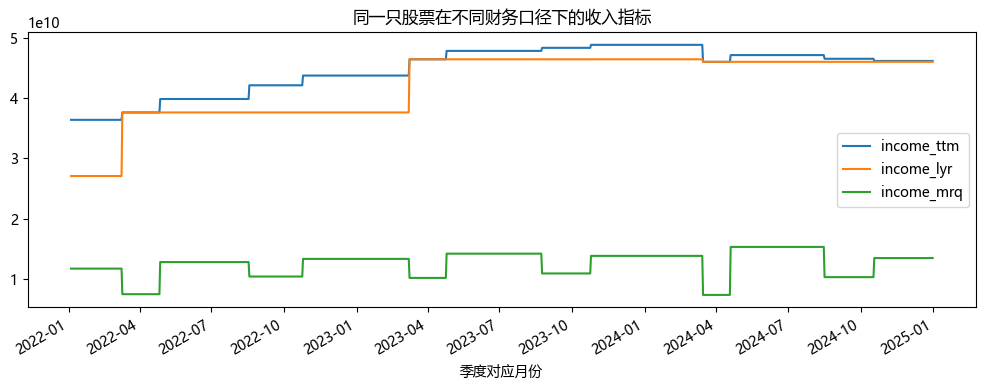

In [11]:
# 选一只股票，画出不同财务口径随时间的变化
# 这里把横坐标改成按季度月份显示（1/4/7/10 月），避免默认月刻度看起来不直观。
import matplotlib.dates as mdates

sample = factor_compare.loc[factor_compare["order_book_id"] == "000001.XSHE"].copy()
sample = sample.sort_values("date")
sample = sample.rename(
    columns={
        "total_income_ttm_0": "income_ttm",
        "total_income_lyr_0": "income_lyr",
        "total_income_mrq_0": "income_mrq",
    }
)

fig, ax = plt.subplots(figsize=(10, 4))
sample.plot(x="date", y=["income_ttm", "income_lyr", "income_mrq"], ax=ax)
ax.set_title("同一只股票在不同财务口径下的收入指标")
ax.set_xlabel("季度对应月份")

# 按季度月份打刻度：1 月、4 月、7 月、10 月
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()


### 2.5 这张图到底在看什么
这张图不是为了比较哪条线更好看，而是帮助学生建立两个直觉：

1. 财务字段不是只有一个“唯一正确数字”
- 同一个概念，可能有滚动口径、年报口径、季度口径

2. 研究时必须先想清楚自己要回答什么问题
- 如果你关心长期经营能力，可能更偏向 `ttm / lyr`
- 如果你关心最近经营变化，可能更偏向 `mrq`


## 3) 衍生因子：价格数据进一步加工后能得到什么
上一节课里我们已经接触过：
- `shift()`
- `rolling()`
- 波动率
- 均线

衍生因子其实就是把这种思路继续推进：
- 趋势类
- 波动类
- 量价类
- 技术指标类

上一届课件里提到过 `Alpha101`，这里保留一个演示版本，不展开全部细节。


### 3.1 为什么说衍生因子并不神秘
因为从代码上看，很多所谓“因子”其实只是：
- 对已有数据做移动窗口统计
- 对收益做累计或标准化
- 对量价关系做再表达

真正重要的不是背公式，而是知道自己在从哪一类数据里提取什么信息。


In [12]:
# 先直接读取平台已经加工好的衍生因子
alpha_demo = rqdatac.get_factor(
    ["000001.XSHE", "600000.XSHG"],
    ["WorldQuant_alpha001", "WorldQuant_alpha005", "WorldQuant_alpha010"],
    start_date=START_DATE,
    end_date=END_DATE,
    expect_df=True,
)

alpha_demo = alpha_demo.reset_index()
alpha_demo.head()


,order_book_id,date,WorldQuant_alpha001,WorldQuant_alpha005,WorldQuant_alpha010
0,000001.XSHE,2022-01-04,-0.294700,-0.078748,0.348092
1,000001.XSHE,2022-01-05,0.391797,-0.116414,0.060798
2,000001.XSHE,2022-01-06,0.154835,-0.252732,0.697168
3,000001.XSHE,2022-01-07,0.426845,-0.477771,0.176970
4,000001.XSHE,2022-01-10,0.210127,-0.262568,0.728124


### 3.2 衍生因子除了 Alpha101 还能怎么讲
旧讲义里除了 `Alpha101`，还会引导大家思考：平台里到底有哪些“技术指标类”信息可以拿。

- 平台已有因子适合快速搭实验
- 自己用 `shift / rolling` 造特征适合理解原理
- 两种方式并不冲突


In [13]:
# 再自己从价格序列加工出两个简单特征：20日动量和20日波动率
price_demo = rqdatac.get_price(
    ["000001.XSHE", "600000.XSHG"],
    start_date=START_DATE,
    end_date=END_DATE,
    fields=["close"],
    adjust_type="pre",
    expect_df=True,
).reset_index()

price_demo = price_demo.sort_values(["order_book_id", "date"]).copy()
price_demo["ret"] = price_demo["close"] / price_demo.groupby("order_book_id")["close"].shift(1) - 1
price_demo["mom_20"] = price_demo["close"] / price_demo.groupby("order_book_id")["close"].shift(20) - 1
price_demo["vol_20"] = (
    price_demo.groupby("order_book_id")["ret"]
    .rolling(20)
    .std()
    .reset_index(level=0, drop=True)
)

price_demo.head(30)


,order_book_id,date,close,ret,mom_20,vol_20
0,000001.XSHE,2022-01-04,13.859992,NaN,NaN,NaN
1,000001.XSHE,2022-01-05,14.267639,0.029412,NaN,NaN
2,000001.XSHE,2022-01-06,14.242681,-0.001749,NaN,NaN
3,000001.XSHE,2022-01-07,14.309236,0.004673,NaN,NaN
4,000001.XSHE,2022-01-10,14.300916,-0.000581,NaN,NaN
5,000001.XSHE,2022-01-11,14.483941,0.012798,NaN,NaN
6,000001.XSHE,2022-01-12,14.142849,-0.023550,NaN,NaN
7,000001.XSHE,2022-01-13,14.126210,-0.001176,NaN,NaN
8,000001.XSHE,2022-01-14,13.585454,-0.038280,NaN,NaN
9,000001.XSHE,2022-01-17,13.493942,-0.006736,NaN,NaN


In [14]:
# 再补一个“自己做技术指标”的例子：5日和20日均线差
price_demo["ma_5"] = (
    price_demo.groupby("order_book_id")["close"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)
price_demo["ma_20"] = (
    price_demo.groupby("order_book_id")["close"]
    .rolling(20)
    .mean()
    .reset_index(level=0, drop=True)
)
price_demo["ma_gap"] = price_demo["ma_5"] / price_demo["ma_20"] - 1

price_demo[["date", "order_book_id", "ma_5", "ma_20", "ma_gap"]].dropna().head()


,date,order_book_id,ma_5,ma_20,ma_gap
19,2022-02-07,000001.XSHE,13.647017,13.983950,-0.024094
20,2022-02-08,000001.XSHE,13.643690,13.991021,-0.024825
21,2022-02-09,000001.XSHE,13.678631,13.978958,-0.021484
22,2022-02-10,000001.XSHE,13.793438,13.973551,-0.012890
23,2022-02-11,000001.XSHE,14.004748,13.969391,0.002531


## 4) 宏观数据：公司之外的外部环境
如果只看个股层面的信息，我们还是少了一块拼图：
- 利率环境
- 流动性环境
- 经济周期

这些变量不一定直接告诉你“下一只股票买谁”，但常常能帮助我们理解市场处在什么状态。


### 4.1 宏观数据在这门课里的定位
这门 workshop 不会把宏观做得特别深，所以你可以把它理解成：
- 它不是这一节的主角
- 但它提醒大家，因子研究不只有公司和价格，还可以有更宏观的背景变量


In [15]:
# 演示两条常见宏观序列
# 1. 存款准备金率
rr = rqdatac.econ.get_reserve_ratio(
    reserve_type="major",
    start_date=START_DATE,
    end_date=END_DATE,
)
# 2. 货币供应量
m2 = rqdatac.econ.get_money_supply(
    start_date=START_DATE,
    end_date=END_DATE,
)


In [16]:
print("reserve_ratio returned columns:", rr.columns.tolist())
display(rr.head())
print("money_supply returned columns:", m2.columns.tolist())
display(m2.head())


reserve_ratio returned columns: ['effective_date', 'reserve_type', 'ratio_floor', 'ratio_ceiling']


,effective_date,reserve_type,ratio_floor,ratio_ceiling
info_date,,,,
2022-04-15,2022-04-25,major_financial_institution,11.25,11.25
2022-11-25,2022-12-05,major_financial_institution,11.00,11.00
2023-03-17,2023-03-27,major_financial_institution,10.75,10.75
2023-09-14,2023-09-15,major_financial_institution,10.50,10.50
2024-01-24,2024-02-05,major_financial_institution,10.00,10.00


money_supply returned columns: ['effective_date', 'm2', 'm1', 'm0', 'm2_growth_yoy', 'm1_growth_yoy', 'm0_growth_yoy']


,effective_date,m2,m1,m0,m2_growth_yoy,m1_growth_yoy,m0_growth_yoy
info_date,,,,,,,
2022-01-30 16:39:13,2021-12-31,238289956.0,64744335.0,9082515.0,0.090,0.035,0.077
2022-03-04 17:42:58,2022-01-31,243102272.0,61385935.0,10618887.0,0.098,-0.019,0.185
2022-03-31 17:18:21,2022-02-28,244148890.0,62161211.0,9722770.0,0.092,0.047,0.058
2022-04-29 00:00:00,2022-03-31,249768834.0,64506380.0,9514192.0,0.097,0.047,0.100
2022-05-30 00:00:00,2022-04-30,249971090.0,63613901.0,9562649.0,0.105,0.051,0.115


In [17]:
# 存款准备金率只画真正的比率列，不把 effective_date 这种日期列画进去。
rr_plot = rr[["ratio_floor", "ratio_ceiling"]].copy()
# M2 这里取同比增速列，不取原始 M2 总量。
m2_plot = m2[["m2_growth_yoy"]].copy()
rr_plot.head(), m2_plot.head()


(            ratio_floor  ratio_ceiling
 info_date                             
 2022-04-15        11.25          11.25
 2022-11-25        11.00          11.00
 2023-03-17        10.75          10.75
 2023-09-14        10.50          10.50
 2024-01-24        10.00          10.00,
                      m2_growth_yoy
 info_date                         
 2022-01-30 16:39:13          0.090
 2022-03-04 17:42:58          0.098
 2022-03-31 17:18:21          0.092
 2022-04-29 00:00:00          0.097
 2022-05-30 00:00:00          0.105)

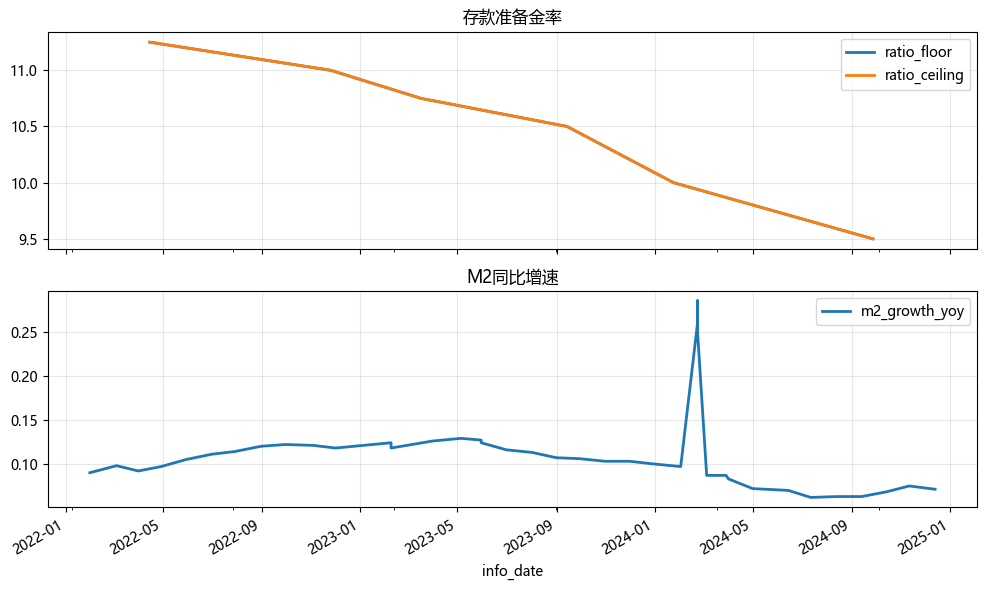

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
rr_plot.plot(ax=axes[0], lw=2, title="存款准备金率")
m2_plot.plot(ax=axes[1], lw=2, title="M2同比增速")
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4.2 宏观变量在回测里通常怎么接
这一节不要求现场把宏观变量接进完整策略，但可以口头说明它常见的两种用途：

1. 直接作为模型特征，和个股因子一起进入预测器
2. 作为市场状态过滤器，例如区分宽松/紧缩环境

这样下一节讲回测时，学生会更容易理解“为什么信号不一定只来自个股本身”。


## 5) 把多来源数据拼成一张因子面板
真正进入多因子研究时，我们不会只看一个字段，而是会把多类信息拼成一张统一的表。

这张表最少应该包含：
- `date`
- `order_book_id`
- 若干个候选因子

后面做标准化、IC 分析、回测，都是从这张表继续往下走。


In [19]:
# 这里做一张最小版本的因子面板
basic_factor = rqdatac.get_factor(
    ["000001.XSHE", "600000.XSHG"],
    ["pe_ratio_ttm"],
    start_date=START_DATE,
    end_date=END_DATE,
    expect_df=True,
).reset_index()

factor_panel = price_demo.merge(
    basic_factor,
    on=["date", "order_book_id"],
    how="left",
)[["date", "order_book_id", "mom_20", "vol_20", "pe_ratio_ttm"]].dropna()

factor_panel.head()


,date,order_book_id,mom_20,vol_20,pe_ratio_ttm
20,2022-02-08,000001.XSHE,0.010204,0.022780,9.157482
21,2022-02-09,000001.XSHE,-0.016910,0.021766,9.173806
22,2022-02-10,000001.XSHE,-0.007593,0.021843,9.244541
23,2022-02-11,000001.XSHE,-0.005814,0.021868,9.304394
24,2022-02-14,000001.XSHE,-0.035486,0.022898,9.021453


### 5.1 为什么这张 `factor_panel` 很关键
你可以把它理解成后面整套多因子流程的“中间层接口”：
- 上游是各种原始数据和衍生数据
- 下游是标准化、IC、回测和组合构建

如果这张表结构不清楚，后面每一步都会变得混乱。


## 6) 课上小练习


### 练习 1：自己读取一个估值因子
要求：
1. 用 `rqdatac.get_factor` 读取 `000001.XSHE` 的 `pb_ratio_ttm`
2. 时间区间使用本节的 `START_DATE` 到 `END_DATE`
3. `reset_index()` 后展示前 5 行


In [20]:
# 练习 1：学生现场自己写
# 提示：get_factor -> reset_index -> head
df = rqdatac.get_factor(
    ['000001.XSHE'],
    ['pb_ratio_ttm'],
    start_date=START_DATE,
    end_date=END_DATE,
    expect_df=True,
).reset_index()

df.head()

,order_book_id,date,pb_ratio_ttm
0,000001.XSHE,2022-01-04,0.860535
1,000001.XSHE,2022-01-05,0.885844
2,000001.XSHE,2022-01-06,0.884295
3,000001.XSHE,2022-01-07,0.888427
4,000001.XSHE,2022-01-10,0.887910


In [21]:
# 参考答案
ex1_factor = rqdatac.get_factor(
    ["000001.XSHE"],
    ["pb_ratio_ttm"],
    start_date=START_DATE,
    end_date=END_DATE,
    expect_df=True,
).reset_index()

ex1_factor.head()


,order_book_id,date,pb_ratio_ttm
0,000001.XSHE,2022-01-04,0.860535
1,000001.XSHE,2022-01-05,0.885844
2,000001.XSHE,2022-01-06,0.884295
3,000001.XSHE,2022-01-07,0.888427
4,000001.XSHE,2022-01-10,0.887910


### 练习 2：自己拼一个两因子面板
要求：
1. 从 `price_demo` 中保留 `date`、`order_book_id`、`mom_20`
2. 再用 `rqdatac.get_factor` 读取 `pb_ratio_ttm`
3. 用 `merge` 把两张表拼起来


In [24]:
# 练习 2：学生现场自己写
# 提示：merge 的键仍然是 date 和 order_book_id
price_new = price_demo[['date', 'order_book_id', 'mom_20']].copy()

df_new = price_new.merge(
    df,
    on=['date', 'order_book_id'],
    how='left',
).dropna()

df_new.head()

,date,order_book_id,mom_20,pb_ratio_ttm
20,2022-02-08,000001.XSHE,0.010204,0.869315
21,2022-02-09,000001.XSHE,-0.016910,0.870865
22,2022-02-10,000001.XSHE,-0.007593,0.877580
23,2022-02-11,000001.XSHE,-0.005814,0.883262
24,2022-02-14,000001.XSHE,-0.035486,0.856402


In [23]:
# 参考答案
ex2_price = price_demo[["date", "order_book_id", "mom_20"]].copy()
ex2_value = rqdatac.get_factor(
    ["000001.XSHE", "600000.XSHG"],
    ["pb_ratio_ttm"],
    start_date=START_DATE,
    end_date=END_DATE,
    expect_df=True,
).reset_index()

ex2_panel = ex2_price.merge(
    ex2_value,
    on=["date", "order_book_id"],
    how="left",
)

ex2_panel.head()


,date,order_book_id,mom_20,pb_ratio_ttm
0,2022-01-04,000001.XSHE,NaN,0.860535
1,2022-01-05,000001.XSHE,NaN,0.885844
2,2022-01-06,000001.XSHE,NaN,0.884295
3,2022-01-07,000001.XSHE,NaN,0.888427
4,2022-01-10,000001.XSHE,NaN,0.887910


## 小结
这一节的关键词是：**因子原料**。

本节结束后，大家应该建立起下面这条链路：
1. 交易数据告诉我们“价格怎么走”
2. 财务数据告诉我们“公司基本面如何”
3. 衍生因子把价格进一步加工成研究特征
4. 宏观数据补充市场外部环境
5. 最终这些信息会被拼成一张 `factor_panel`

本节常见易错点：
1. 把 `ttm / lyr / mrq` 混在一起，不问自己到底在看什么口径
2. 忽略财务数据的披露时点，误用未来信息
3. 只会取单个字段，不会把多来源数据组织成统一面板

下一节我们会把这些信号真正接进回测框架，回答“如果按规则交易，净值会怎样变化”。
